In [569]:
#%matplotlib notebook
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd


In [570]:
df = pd.read_csv('happiness_2017.csv')


In [571]:
df

,Country,Region,Rank,HappinessScore,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government
0,Norway,Western Europe,1,7.537,7.578745,11.081789,0.950128,71.086586,0.953017,0.210104,0.249711,0.849100,0.202914,0.717160
1,Denmark,Western Europe,2,7.522,7.593702,10.748989,0.952100,71.662498,0.955416,0.145387,0.181148,0.823667,0.205775,0.572353
2,Iceland,Western Europe,3,7.504,7.476214,10.760409,0.966753,72.755981,0.938783,0.235479,0.726845,0.895255,0.148160,0.365042
3,Switzerland,Western Europe,4,7.494,7.473593,10.955548,0.949661,73.173759,0.924997,0.167875,0.316183,0.773997,0.195871,0.819707
4,Finland,Western Europe,5,7.469,7.788252,10.612338,0.963826,71.696960,0.962199,-0.012174,0.192413,0.787137,0.176066,0.597539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,Liberia,Sub-Saharan Africa,136,3.533,4.424491,6.629414,0.684867,52.786850,0.733390,0.040577,0.866806,0.667946,0.391331,0.554992
136,Guinea,Sub-Saharan Africa,137,3.507,4.873723,7.527477,0.634026,51.151817,0.738213,0.054308,0.750026,0.704477,0.422461,0.639981
137,Togo,Sub-Saharan Africa,138,3.495,4.360805,7.251670,0.507805,52.257275,0.716694,-0.037704,0.725520,0.614189,0.425824,0.484952
138,Tanzania,Sub-Saharan Africa,139,3.349,3.347121,7.896314,0.705010,56.665485,0.800496,0.106599,0.653606,0.714646,0.255336,0.913339


In [572]:
df.isna().any()

Country                              False
Region                               False
Rank                                 False
HappinessScore                       False
Life Ladder                          False
Log GDP per capita                    True
Social support                        True
Healthy life expectancy at birth     False
Freedom to make life choices          True
Generosity                            True
Perceptions of corruption             True
Positive affect                       True
Negative affect                       True
Confidence in national government     True
dtype: bool

    Load the built-in low-resolution shapefile with country geometries from GeoPandas into a GeoDataFrame.

In [573]:
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

    Merge the happiness dataset with the GeoDataFrame using an outer join, matching the country names.

In [574]:
df[~df['Country'].isin(world['name'])]

,Country,Region,Rank,HappinessScore,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government
12,United States,North America and ANZ,13,6.993,6.991759,10.899869,0.921003,69.770920,0.868497,0.181657,0.681191,0.826555,0.268269,0.386535
21,Czech Republic,Central and Eastern Europe,22,6.609,6.789568,10.393459,0.900969,71.451027,0.831785,-0.184590,0.866525,0.738744,0.226650,0.343871
24,Singapore,Southeast Asia,25,6.572,6.378438,11.317050,0.897350,75.812401,0.926128,0.120412,0.161791,0.800114,0.179325,0.926998
25,Malta,Western Europe,26,6.527,6.675666,10.502700,0.937332,71.829514,0.923643,0.241762,0.690495,0.720753,0.302443,0.752005
31,Taiwan Province of China,East Asia,32,6.422,6.359451,NaN,0.891119,71.209999,0.759655,NaN,0.742780,0.837277,0.114123,0.322822
38,Bahrain,Middle East and North Africa,39,6.087,6.227321,10.686713,0.875747,66.123993,0.905859,0.120759,NaN,0.813571,0.289760,NaN
58,Mauritius,Sub-Saharan Africa,59,5.629,6.174118,9.914655,0.910142,65.589157,0.912308,0.073929,0.818180,0.747760,0.168721,0.614671
64,"Hong Kong S.A.R., China",East Asia,65,5.472,5.362475,10.917167,0.831066,76.536362,0.830657,0.122935,0.415810,0.639533,0.200593,0.545041
78,Dominican Republic,Latin America and Caribbean,79,5.230,5.605203,9.594574,0.894368,63.495995,0.855359,-0.127092,0.760490,0.738944,0.274746,0.459901
82,Bosnia and Herzegovina,Central and Eastern Europe,83,5.182,5.089902,9.371713,0.775295,67.994484,0.563799,0.089589,0.923343,0.597342,0.270746,0.126380


In [575]:
merged = world.merge(df, left_on='name', right_on='Country', how='left')

In [576]:
merged[merged['continent'] == 'North America']

,pop_est,continent,name,iso_a3,gdp_md_est,geometry,Country,Region,Rank,HappinessScore,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government
3,37589262.0,North America,Canada,CAN,1736425,"MULTIPOLYGON (((-122.84000 49.00000, -122.9742...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,328239523.0,North America,United States of America,USA,21433226,"MULTIPOLYGON (((-122.84000 49.00000, -120.0000...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,11263077.0,North America,Haiti,HTI,14332,"POLYGON ((-71.71236 19.71446, -71.62487 19.169...",Haiti,Latin America and Caribbean,133.0,3.603,3.823866,7.403176,0.646985,53.347008,0.484429,0.384510,0.647192,0.573367,0.321693,0.435077
17,10738958.0,North America,Dominican Rep.,DOM,88941,"POLYGON ((-71.70830 18.04500, -71.68774 18.316...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,389482.0,North America,Bahamas,BHS,13578,"MULTIPOLYGON (((-78.98000 26.79000, -78.51000 ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,56225.0,North America,Greenland,GRL,3051,"POLYGON ((-46.76379 82.62796, -43.40644 83.225...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,127575529.0,North America,Mexico,MEX,1268870,"POLYGON ((-117.12776 32.53534, -115.99135 32.6...",Mexico,Latin America and Caribbean,24.0,6.578,6.410299,9.741969,0.799839,68.098228,0.861405,-0.206639,0.800893,0.842642,0.230991,0.256953
33,4246439.0,North America,Panama,PAN,66800,"POLYGON ((-77.35336 8.67050, -77.47472 8.52429...",Panama,Latin America and Caribbean,29.0,6.452,6.567659,10.002714,0.911905,68.045410,0.899574,-0.164080,0.840777,0.832689,0.242319,0.390996
34,5047561.0,North America,Costa Rica,CRI,61801,"POLYGON ((-82.54620 9.56613, -82.93289 9.47681...",Costa Rica,Latin America and Caribbean,11.0,7.079,7.225182,9.670634,0.921697,69.867302,0.935618,-0.078269,0.742351,0.874396,0.275440,0.407448
35,6545502.0,North America,Nicaragua,NIC,12520,"POLYGON ((-83.65561 10.93876, -83.89505 10.726...",Nicaragua,Latin America and Caribbean,40.0,6.071,6.476357,8.575318,0.838044,66.251785,0.922163,0.010327,0.672963,0.849764,0.308448,0.590425


In [577]:
merged[~merged['Country'].isin(df['Country'])]

,pop_est,continent,name,iso_a3,gdp_md_est,geometry,Country,Region,Rank,HappinessScore,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government
0,889953.0,Oceania,Fiji,FJI,5496,"MULTIPOLYGON (((180.00000 -16.06713, 180.00000...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,603253.0,Africa,W. Sahara,ESH,907,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,37589262.0,North America,Canada,CAN,1736425,"MULTIPOLYGON (((-122.84000 49.00000, -122.9742...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,328239523.0,North America,United States of America,USA,21433226,"MULTIPOLYGON (((-122.84000 49.00000, -120.0000...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8776109.0,Oceania,Papua New Guinea,PNG,24829,"MULTIPOLYGON (((141.00021 -2.60015, 142.73525 ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,86790567.0,Africa,Dem. Rep. Congo,COD,50400,"POLYGON ((29.34000 -4.49998, 29.51999 -5.41998...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,10192317.3,Africa,Somalia,SOM,4719,"POLYGON ((41.58513 -1.68325, 40.99300 -0.85829...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,42813238.0,Africa,Sudan,SDN,30513,"POLYGON ((24.56737 8.22919, 23.80581 8.66632, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,10738958.0,North America,Dominican Rep.,DOM,88941,"POLYGON ((-71.70830 18.04500, -71.68774 18.316...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,389482.0,North America,Bahamas,BHS,13578,"MULTIPOLYGON (((-78.98000 26.79000, -78.51000 ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [578]:
merged.loc[merged['name'] == 'United States of America', 'HappinessScore'] = 6.993

In [579]:
merged

,pop_est,continent,name,iso_a3,gdp_md_est,geometry,Country,Region,Rank,HappinessScore,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government
0,889953.0,Oceania,Fiji,FJI,5496,"MULTIPOLYGON (((180.00000 -16.06713, 180.00000...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,58005463.0,Africa,Tanzania,TZA,63177,"POLYGON ((33.90371 -0.95000, 34.07262 -1.05982...",Tanzania,Sub-Saharan Africa,139.0,3.349,3.347121,7.896314,0.705010,56.665485,0.800496,0.106599,0.653606,0.714646,0.255336,0.913339
2,603253.0,Africa,W. Sahara,ESH,907,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,37589262.0,North America,Canada,CAN,1736425,"MULTIPOLYGON (((-122.84000 49.00000, -122.9742...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,328239523.0,North America,United States of America,USA,21433226,"MULTIPOLYGON (((-122.84000 49.00000, -120.0000...",NaN,NaN,NaN,6.993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,6944975.0,Europe,Serbia,SRB,51475,"POLYGON ((18.82982 45.90887, 18.82984 45.90888...",Serbia,Central and Eastern Europe,67.0,5.395,5.122031,9.561538,0.883770,65.684875,0.684846,-0.081416,0.851458,0.509721,0.326407,0.511198
173,622137.0,Europe,Montenegro,MNE,5542,"POLYGON ((20.07070 42.58863, 19.80161 42.50009...",Montenegro,Central and Eastern Europe,76.0,5.237,5.614799,9.694497,0.881200,67.142189,0.625906,-0.084891,0.755680,0.519128,0.349785,0.351550
174,1794248.0,Europe,Kosovo,-99,7926,"POLYGON ((20.59025 41.85541, 20.52295 42.21787...",Kosovo,Central and Eastern Europe,72.0,5.279,6.149200,NaN,0.792087,62.392479,0.857677,NaN,0.925192,0.738436,0.185879,0.298196
175,1394973.0,North America,Trinidad and Tobago,TTO,24269,"POLYGON ((-61.68000 10.76000, -61.10500 10.890...",Trinidad and Tobago,Latin America and Caribbean,36.0,6.168,6.191860,10.323865,0.916029,61.738312,0.859140,-0.014604,0.911336,0.846467,0.248099,0.272541


In [580]:
merged['name']

0                          Fiji
1                      Tanzania
2                     W. Sahara
3                        Canada
4      United States of America
                 ...           
172                      Serbia
173                  Montenegro
174                      Kosovo
175         Trinidad and Tobago
176                    S. Sudan
Name: name, Length: 177, dtype: object

    Normalize the happiness scores to a range of 0 to 1, which helps with visualization.

In [581]:
merged['HappinessScore'] = (merged['HappinessScore'] - merged['HappinessScore'].min()) / (merged['HappinessScore'].max() - merged['HappinessScore'].min())

    Set a default value of -1 for countries without a Happiness Score. 

In [582]:
default_happiness_score = -1

In [583]:
merged['HappinessScore'].fillna(default_happiness_score, inplace=True)

<IPython.core.display.Javascript object>


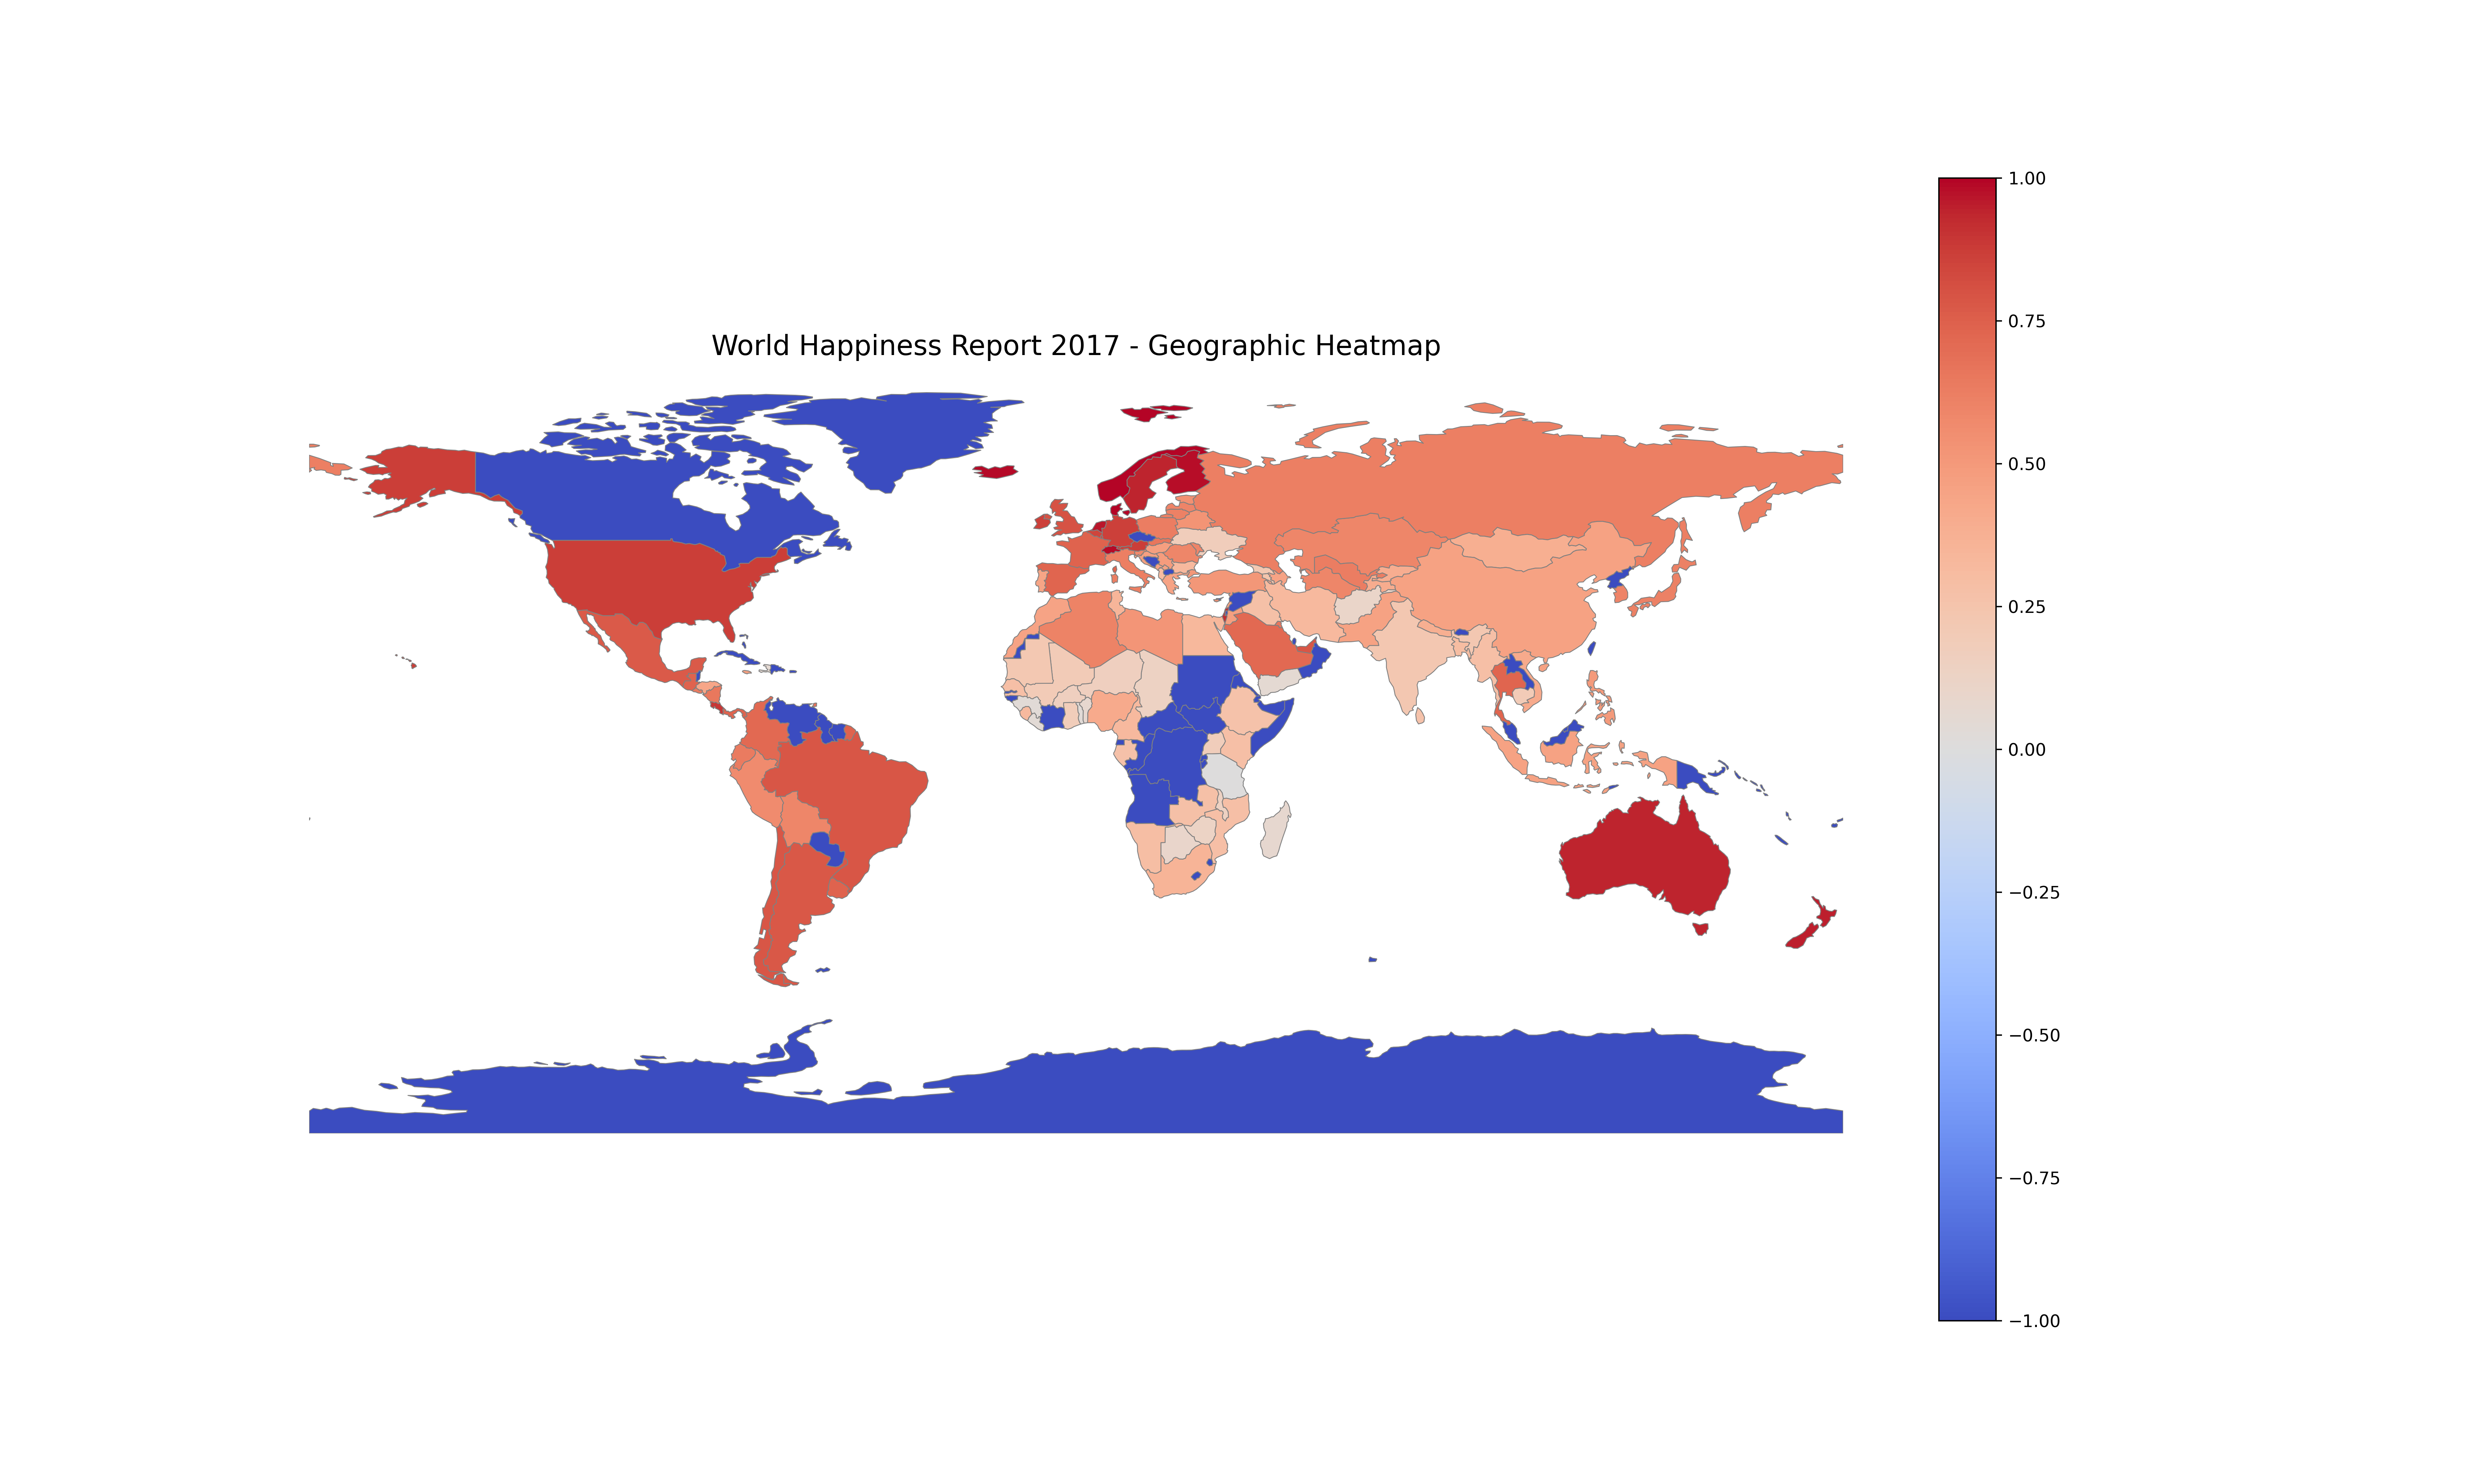

In [584]:
fig, ax = plt.subplots(1, 1, figsize=(20, 12))
merged.plot(column='HappinessScore', cmap='coolwarm', linewidth=0.5, ax=ax, edgecolor='0.5', legend=True)
plt.show()

In [585]:
ax.set_title("World Happiness Report 2017 - Geographic Heatmap", fontsize=16)
ax.set_axis_off()
ax.set_xlim([-180, 180])
ax.set_ylim([-90, 90])

(-90.0, 90.0)

In [586]:
continents = ['Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania']

In [587]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
axes = axes.flatten()

In [588]:
for ax, continent in zip(axes, continents):
    continent_data = merged[merged['continent'] == continent]
    continent_data.plot(column='HappinessScore', cmap='coolwarm', linewidth=0.5, ax=ax, edgecolor='0.5', legend=True)
    ax.set_title(f"{continent} - HappinessScore", fontsize=16)
    ax.set_axis_off()


In [589]:
plt.subplots_adjust(wspace=0.2, hspace=0.2)

<IPython.core.display.Javascript object>


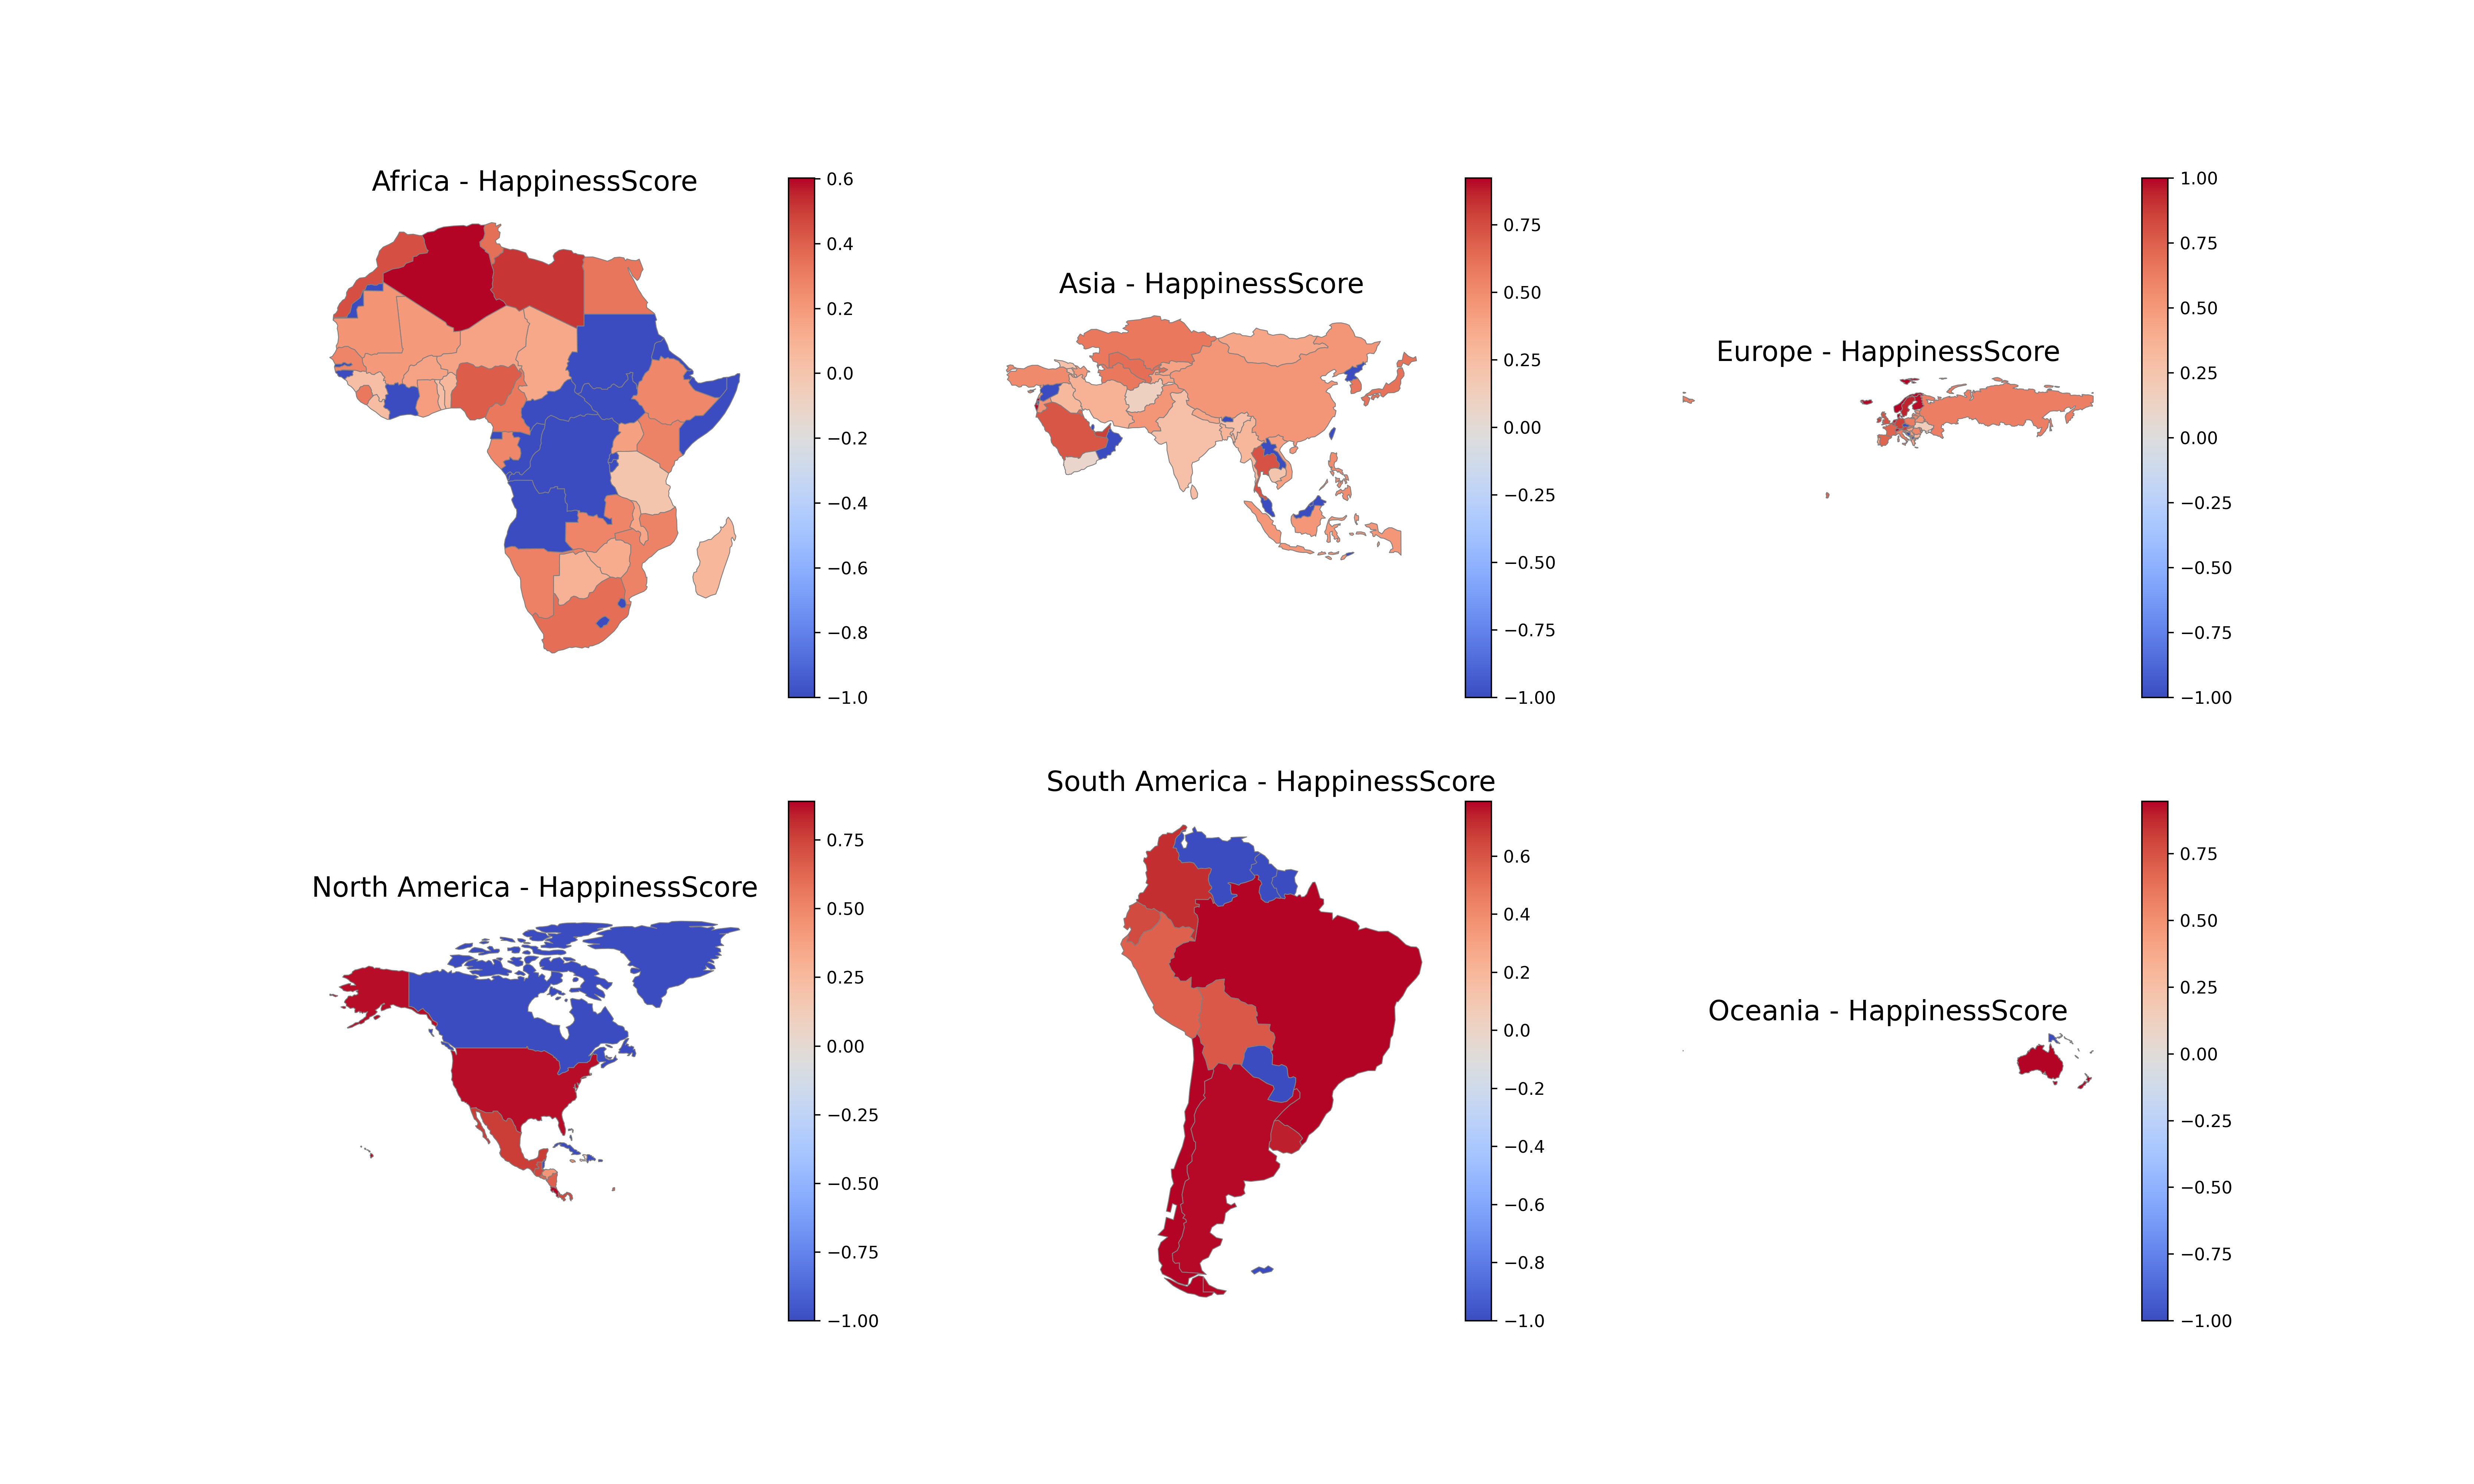

In [590]:
plt.show()

 Define a dictionary that maps continents to their corresponding color palettes.

In [591]:
continent_color_map = {
    'Africa': 'Blues',
    'Asia': 'Greens',
    'Europe': 'Reds',
    'North America': 'Purples',
    'South America': 'Oranges',
    'Oceania': 'YlOrBr'
}

Create a base plot using the subplots function from matplotlib, setting the figure size.

In [592]:
fig, ax = plt.subplots(1, figsize=(20, 12))

Iterate through each continent and its color palette, creating a choropleth map for each continent with the specified color palette, and add it to the base plot.

In [593]:
for continent, cmap in continent_color_map.items():
    continent_data = merged[merged['continent'] == continent]
    continent_data.plot(column='HappinessScore', cmap=cmap, linewidth=0.5, ax=ax, edgecolor='0.5')


Customize the plot by setting the title, turning off the axis, and setting the x and y limits.

In [594]:
ax.set_title("World Happiness Report 2017 - Geographic Heatmap (Different Color Palettes per Continent)", fontsize=16)
ax.set_axis_off()
ax.set_xlim([-180, 180])
ax.set_ylim([-90, 90])

(-90.0, 90.0)

<IPython.core.display.Javascript object>


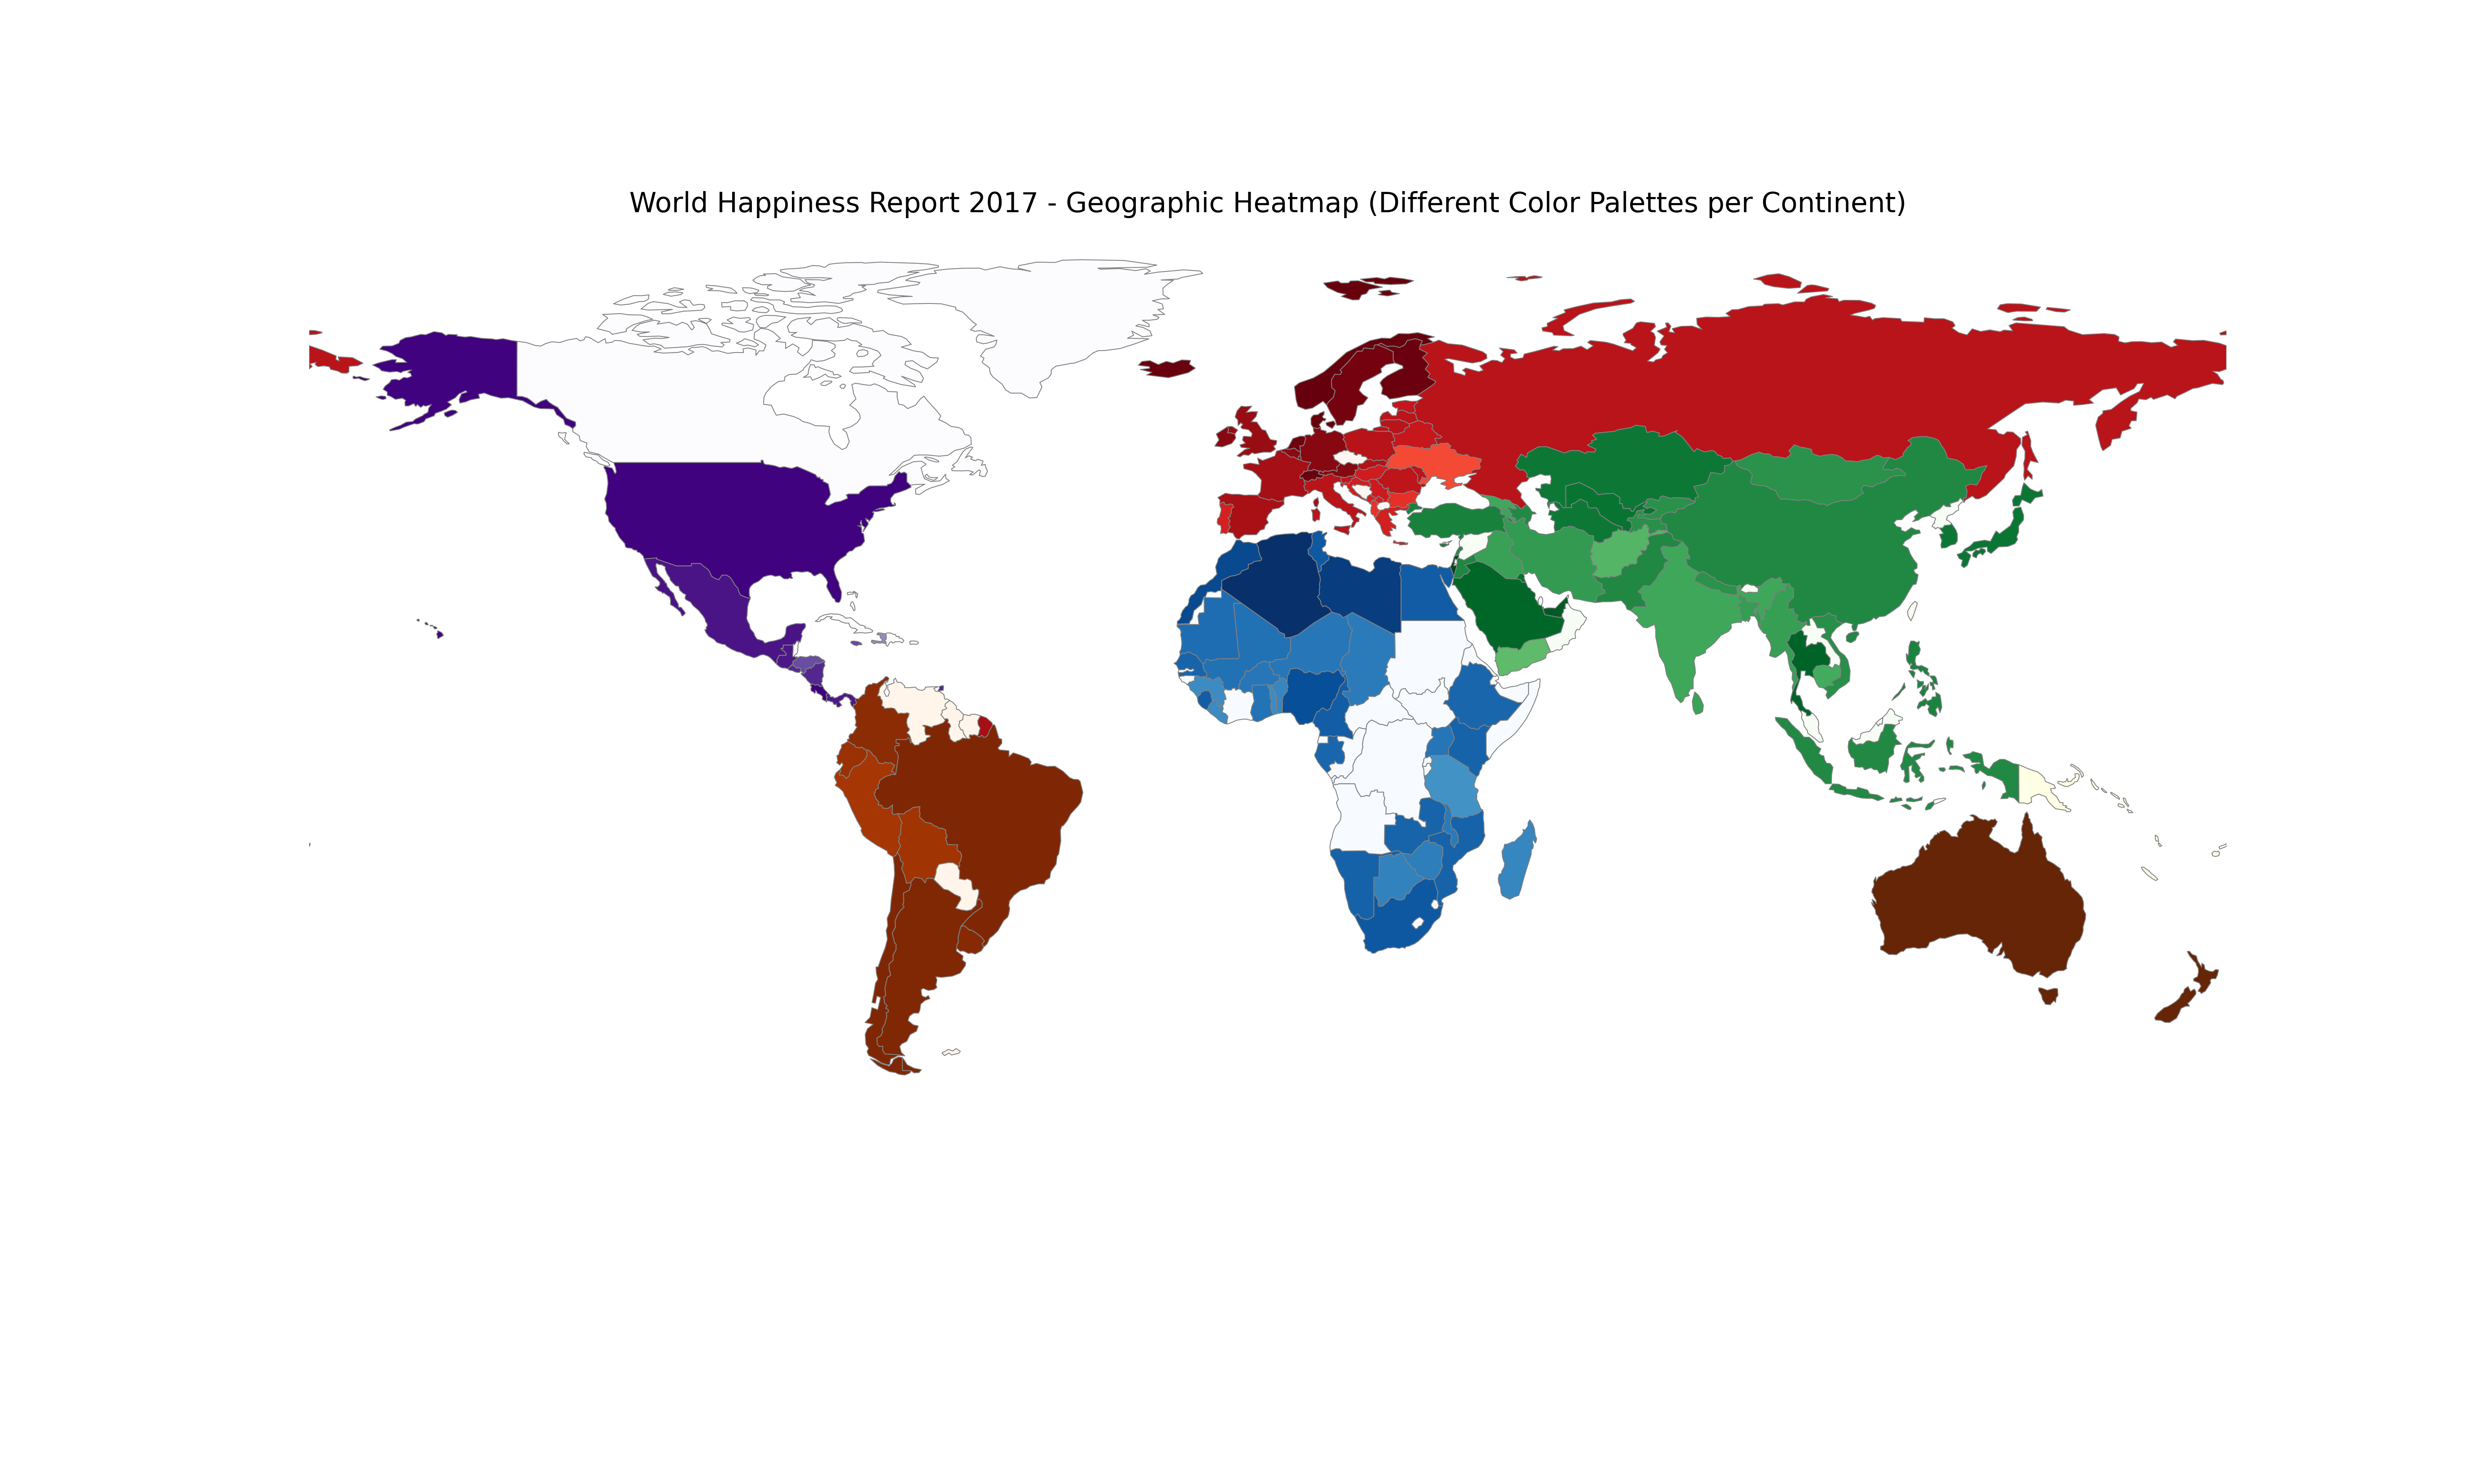

In [595]:
plt.show()